In [1]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import h5py
import matplotlib.pyplot as plt
import os
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, roc_curve

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
print("PyTorch:", torch.__version__)

Mounted at /content/drive
Device: cuda
PyTorch: 2.10.0+cu128


In [2]:
file_path = '/content/drive/MyDrive/quark-gluon_data-set_n139306 (1).hdf5'

print("Loading data...")
with h5py.File(file_path, 'r') as f:
    X_data = f['X_jets'][:20000]
    y_data = f['y'][:20000]
print(f"Loaded: {X_data.shape}")

Loading data...
Loaded: (20000, 125, 125, 3)


In [3]:
def image_to_pointcloud(image, threshold=0.0):
    mask = np.any(image > threshold, axis=-1)
    coords = np.argwhere(mask)
    if len(coords) == 0:
        return np.zeros((1, 5), dtype=np.float32)
    x = coords[:, 0] / 124.0
    y = coords[:, 1] / 124.0
    ecal   = image[coords[:, 0], coords[:, 1], 0]
    hcal   = image[coords[:, 0], coords[:, 1], 1]
    tracks = image[coords[:, 0], coords[:, 1], 2]
    return np.stack([x, y, ecal, hcal, tracks], axis=1).astype(np.float32)

In [4]:
import gc

print("Pre-processing point clouds...")
MAX_NODES = 100
X_pc = np.zeros((len(X_data), MAX_NODES, 5), dtype=np.float32)

for i in range(len(X_data)):
    pc = image_to_pointcloud(X_data[i])
    if len(pc) > MAX_NODES:
        energy = pc[:, 2] + pc[:, 3] + pc[:, 4]
        pc = pc[np.argsort(energy)[-MAX_NODES:]]
    pad = MAX_NODES - len(pc)
    if pad > 0:
        pc = np.vstack([pc, np.zeros((pad, 5), dtype=np.float32)])
    X_pc[i] = pc
    if i % 5000 == 0:
        print(f"  {i}/{len(X_data)}")

del X_data
gc.collect()
print(f"Done! Shape: {X_pc.shape}")

class JetGraphDataset(Dataset):
    def __init__(self, X_pc, y):
        self.X = torch.tensor(X_pc, dtype=torch.float32)
        self.y = torch.tensor(y,    dtype=torch.float32)
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

indices   = np.random.permutation(20000)
train_idx = indices[:16000]
val_idx   = indices[16000:]

train_ds = JetGraphDataset(X_pc[train_idx], y_data[train_idx])
val_ds   = JetGraphDataset(X_pc[val_idx],   y_data[val_idx])

del X_pc
gc.collect()

train_loader = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Pre-processing point clouds...
  0/20000
  5000/20000
  10000/20000
  15000/20000
Done! Shape: (20000, 100, 5)
Train: 16000 | Val: 4000


In [5]:
class GNNClassifier(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=128):
        super(GNNClassifier, self).__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )
        self.lin1 = nn.Linear(hidden_dim, hidden_dim)
        self.bn1  = nn.BatchNorm1d(hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, hidden_dim)
        self.bn2  = nn.BatchNorm1d(hidden_dim)
        self.lin3 = nn.Linear(hidden_dim, hidden_dim)
        self.bn3  = nn.BatchNorm1d(hidden_dim)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        B, N, _ = x.shape
        x = self.input_proj(x.view(B*N, -1)).view(B, N, -1)
        x = F.relu(self.bn1(self.lin1(x.view(B*N, -1)))).view(B, N, -1)
        x = F.relu(self.bn2(self.lin2(x.view(B*N, -1)))).view(B, N, -1)
        x = F.relu(self.bn3(self.lin3(x.view(B*N, -1)))).view(B, N, -1)
        mean_pool = x.mean(dim=1)
        max_pool  = x.max(dim=1).values
        return self.classifier(torch.cat([mean_pool, max_pool], dim=-1)).squeeze(-1)

model_gnn = GNNClassifier(input_dim=5, hidden_dim=128).to(device)
print(f"Baseline GNN params: {sum(p.numel() for p in model_gnn.parameters()):,}")

Baseline GNN params: 92,545


In [6]:
class NonLocalBlock(nn.Module):
    def __init__(self, in_channels):
        super(NonLocalBlock, self).__init__()
        self.inter_channels = in_channels // 2
        self.theta = nn.Linear(in_channels, self.inter_channels)
        self.phi   = nn.Linear(in_channels, self.inter_channels)
        self.g     = nn.Linear(in_channels, self.inter_channels)
        self.out   = nn.Linear(self.inter_channels, in_channels)
        self.bn    = nn.BatchNorm1d(in_channels)

    def forward(self, x):
        B, N, C = x.shape
        theta = self.theta(x)
        phi   = self.phi(x)
        g     = self.g(x)
        attn  = F.softmax(torch.bmm(theta, phi.transpose(1,2)) / (self.inter_channels**0.5), dim=-1)
        out   = self.out(torch.bmm(attn, g)) + x
        return self.bn(out.view(B*N, C)).view(B, N, C)

class NonLocalGNN(nn.Module):
    def __init__(self, input_dim=5, hidden_dim=128):
        super(NonLocalGNN, self).__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU()
        )
        self.nonlocal1 = NonLocalBlock(hidden_dim)
        self.lin1      = nn.Linear(hidden_dim, hidden_dim)
        self.bn1       = nn.BatchNorm1d(hidden_dim)
        self.nonlocal2 = NonLocalBlock(hidden_dim)
        self.lin2      = nn.Linear(hidden_dim, hidden_dim)
        self.bn2       = nn.BatchNorm1d(hidden_dim)
        self.nonlocal3 = NonLocalBlock(hidden_dim)
        self.lin3      = nn.Linear(hidden_dim, hidden_dim)
        self.bn3       = nn.BatchNorm1d(hidden_dim)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )

    def forward(self, x):
        B, N, _ = x.shape
        x = self.input_proj(x.view(B*N, -1)).view(B, N, -1)
        x = self.nonlocal1(x)
        x = F.relu(self.bn1(self.lin1(x.view(B*N,-1)))).view(B,N,-1)
        x = self.nonlocal2(x)
        x = F.relu(self.bn2(self.lin2(x.view(B*N,-1)))).view(B,N,-1)
        x = self.nonlocal3(x)
        x = F.relu(self.bn3(self.lin3(x.view(B*N,-1)))).view(B,N,-1)
        mean_pool = x.mean(dim=1)
        max_pool  = x.max(dim=1).values
        return self.classifier(torch.cat([mean_pool, max_pool], dim=-1)).squeeze(-1)

model_nl = NonLocalGNN(input_dim=5, hidden_dim=128).to(device)
print(f"Non-local GNN params: {sum(p.numel() for p in model_nl.parameters()):,}")

Non-local GNN params: 192,577


In [7]:
criterion = nn.BCEWithLogitsLoss()

def train_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        loss = criterion(model(X), y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_epoch(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    total_loss = 0
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            total_loss += criterion(logits, y).item()
            all_preds.extend(torch.sigmoid(logits).cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    return total_loss/len(loader), roc_auc_score(all_labels, all_preds), all_preds, all_labels

In [8]:
num_epochs = 30
base_aucs, nl_aucs = [], []

# Baseline GNN
print("=" * 50)
print("Training Baseline GNN...")
print("=" * 50)
opt_gnn   = torch.optim.Adam(model_gnn.parameters(), lr=3e-4, weight_decay=1e-4)
sched_gnn = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_gnn, mode='max', patience=3, factor=0.5)
best_base_auc = 0

for epoch in range(num_epochs):
    tl = train_epoch(model_gnn, train_loader, opt_gnn)
    vl, auc, _, _ = eval_epoch(model_gnn, val_loader)
    base_aucs.append(auc)
    sched_gnn.step(auc)
    if auc > best_base_auc:
        best_base_auc = auc
        torch.save(model_gnn.state_dict(), '/content/best_baseline.pth')
    print(f"Epoch [{epoch+1:2d}/{num_epochs}] | Loss: {tl:.4f} | AUC: {auc:.4f} {'★' if auc == best_base_auc else ''}")

print(f"\nBest Baseline AUC: {best_base_auc:.4f}")

# Non-local GNN
print("\n" + "=" * 50)
print("Training Non-local GNN...")
print("=" * 50)
opt_nl   = torch.optim.Adam(model_nl.parameters(), lr=3e-4, weight_decay=1e-4)
sched_nl = torch.optim.lr_scheduler.ReduceLROnPlateau(opt_nl, mode='max', patience=3, factor=0.5)
best_nl_auc = 0

for epoch in range(num_epochs):
    tl = train_epoch(model_nl, train_loader, opt_nl)
    vl, auc, _, _ = eval_epoch(model_nl, val_loader)
    nl_aucs.append(auc)
    sched_nl.step(auc)
    if auc > best_nl_auc:
        best_nl_auc = auc
        torch.save(model_nl.state_dict(), '/content/best_nonlocal.pth')
    print(f"Epoch [{epoch+1:2d}/{num_epochs}] | Loss: {tl:.4f} | AUC: {auc:.4f} {'★' if auc == best_nl_auc else ''}")

print(f"\nBest Non-local AUC: {best_nl_auc:.4f}")
print(f"Improvement: {(best_nl_auc - best_base_auc)*100:.2f}%")

Training Baseline GNN...
Epoch [ 1/30] | Loss: 0.6309 | AUC: 0.7346 ★
Epoch [ 2/30] | Loss: 0.6104 | AUC: 0.7487 ★
Epoch [ 3/30] | Loss: 0.5998 | AUC: 0.7592 ★
Epoch [ 4/30] | Loss: 0.5897 | AUC: 0.7682 ★
Epoch [ 5/30] | Loss: 0.5816 | AUC: 0.7738 ★
Epoch [ 6/30] | Loss: 0.5768 | AUC: 0.7641 
Epoch [ 7/30] | Loss: 0.5763 | AUC: 0.7798 ★
Epoch [ 8/30] | Loss: 0.5731 | AUC: 0.7817 ★
Epoch [ 9/30] | Loss: 0.5670 | AUC: 0.7800 
Epoch [10/30] | Loss: 0.5661 | AUC: 0.7828 ★
Epoch [11/30] | Loss: 0.5645 | AUC: 0.7857 ★
Epoch [12/30] | Loss: 0.5618 | AUC: 0.7819 
Epoch [13/30] | Loss: 0.5601 | AUC: 0.7839 
Epoch [14/30] | Loss: 0.5593 | AUC: 0.7854 
Epoch [15/30] | Loss: 0.5603 | AUC: 0.7813 
Epoch [16/30] | Loss: 0.5543 | AUC: 0.7892 ★
Epoch [17/30] | Loss: 0.5513 | AUC: 0.7796 
Epoch [18/30] | Loss: 0.5516 | AUC: 0.7863 
Epoch [19/30] | Loss: 0.5517 | AUC: 0.7893 ★
Epoch [20/30] | Loss: 0.5466 | AUC: 0.7870 
Epoch [21/30] | Loss: 0.5472 | AUC: 0.7883 
Epoch [22/30] | Loss: 0.5441 | AUC: 0.78

In [9]:
model_nl2 = NonLocalGNN(input_dim=5, hidden_dim=128).to(device)
opt_nl2   = torch.optim.Adam(model_nl2.parameters(), lr=3e-4, weight_decay=1e-4)
sched_nl2 = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt_nl2, T_0=10, T_mult=2)

best_nl2_auc = 0
num_epochs = 50
nl2_aucs = []

print("Training Improved Non-local GNN (50 epochs)...")
for epoch in range(num_epochs):
    tl = train_epoch(model_nl2, train_loader, opt_nl2)
    vl, auc, _, _ = eval_epoch(model_nl2, val_loader)
    nl2_aucs.append(auc)
    sched_nl2.step()
    if auc > best_nl2_auc:
        best_nl2_auc = auc
        torch.save(model_nl2.state_dict(), '/content/best_nonlocal2.pth')
    print(f"Epoch [{epoch+1:2d}/{num_epochs}] | Loss: {tl:.4f} | AUC: {auc:.4f} {'★' if auc == best_nl2_auc else ''}")

print(f"\nBest Non-local AUC: {best_nl2_auc:.4f}")

Training Improved Non-local GNN (50 epochs)...
Epoch [ 1/50] | Loss: 0.6280 | AUC: 0.7423 ★
Epoch [ 2/50] | Loss: 0.5973 | AUC: 0.7611 ★
Epoch [ 3/50] | Loss: 0.5800 | AUC: 0.7712 ★
Epoch [ 4/50] | Loss: 0.5732 | AUC: 0.7778 ★
Epoch [ 5/50] | Loss: 0.5667 | AUC: 0.7793 ★
Epoch [ 6/50] | Loss: 0.5639 | AUC: 0.7846 ★
Epoch [ 7/50] | Loss: 0.5573 | AUC: 0.7838 
Epoch [ 8/50] | Loss: 0.5573 | AUC: 0.7674 
Epoch [ 9/50] | Loss: 0.5532 | AUC: 0.7864 ★
Epoch [10/50] | Loss: 0.5537 | AUC: 0.7759 
Epoch [11/50] | Loss: 0.5637 | AUC: 0.7684 
Epoch [12/50] | Loss: 0.5618 | AUC: 0.7751 
Epoch [13/50] | Loss: 0.5613 | AUC: 0.7662 
Epoch [14/50] | Loss: 0.5562 | AUC: 0.7794 
Epoch [15/50] | Loss: 0.5546 | AUC: 0.7838 
Epoch [16/50] | Loss: 0.5534 | AUC: 0.7759 
Epoch [17/50] | Loss: 0.5507 | AUC: 0.7833 
Epoch [18/50] | Loss: 0.5509 | AUC: 0.7904 ★
Epoch [19/50] | Loss: 0.5478 | AUC: 0.7569 
Epoch [20/50] | Loss: 0.5455 | AUC: 0.7866 
Epoch [21/50] | Loss: 0.5450 | AUC: 0.7874 
Epoch [22/50] | Loss:

In [10]:
model_nl.load_state_dict(torch.load('/content/best_nonlocal.pth'))
_, nl_auc, nl_preds, nl_labels = eval_epoch(model_nl, val_loader)
print(f"Final Non-local AUC: {nl_auc:.4f}")

Final Non-local AUC: 0.7954


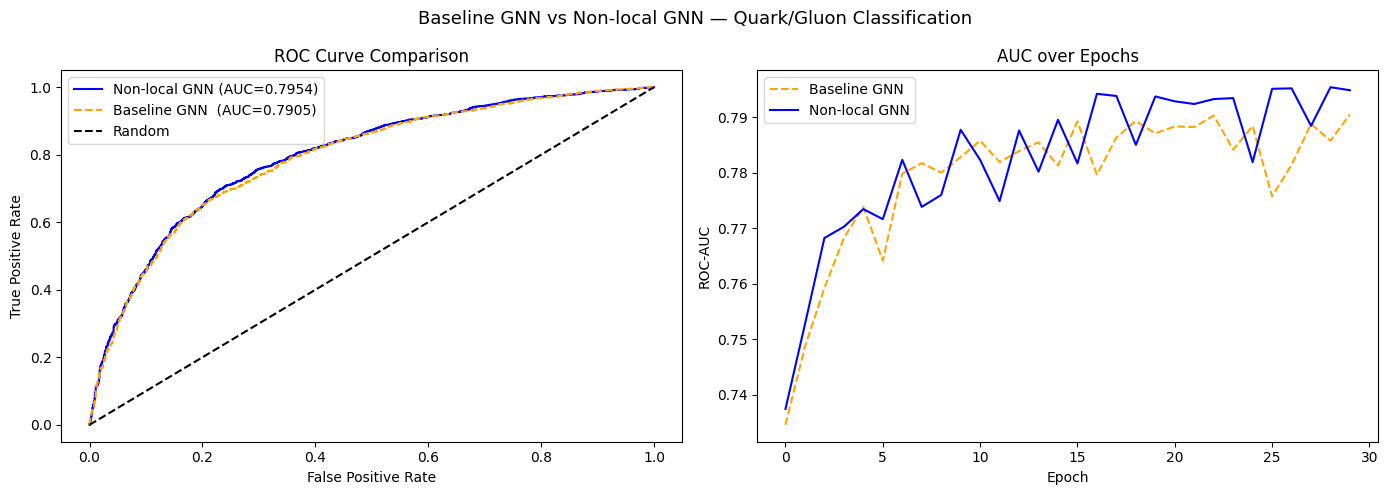

Baseline GNN  AUC: 0.7905
Non-local GNN AUC: 0.7954
Improvement:       0.49%


In [11]:
model_gnn.load_state_dict(torch.load('/content/best_baseline.pth'))
model_nl.load_state_dict(torch.load('/content/best_nonlocal.pth'))

_, base_auc, base_preds, base_labels = eval_epoch(model_gnn, val_loader)
_, nl_auc,   nl_preds,   nl_labels   = eval_epoch(model_nl,  val_loader)

fpr_b, tpr_b, _ = roc_curve(base_labels, base_preds)
fpr_n, tpr_n, _ = roc_curve(nl_labels,   nl_preds)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(fpr_n, tpr_n, label=f'Non-local GNN (AUC={nl_auc:.4f})',   color='blue')
ax1.plot(fpr_b, tpr_b, label=f'Baseline GNN  (AUC={base_auc:.4f})', color='orange', linestyle='--')
ax1.plot([0,1],[0,1],'k--', label='Random')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve Comparison')
ax1.legend()

ax2.plot(base_aucs, label='Baseline GNN',  color='orange', linestyle='--')
ax2.plot(nl_aucs,   label='Non-local GNN', color='blue')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('ROC-AUC')
ax2.set_title('AUC over Epochs')
ax2.legend()

plt.suptitle('Baseline GNN vs Non-local GNN — Quark/Gluon Classification', fontsize=13)
plt.tight_layout()

os.makedirs('/content/Genie-Task/specific_task', exist_ok=True)
plt.savefig('/content/Genie-Task/specific_task/comparison_roc.png', dpi=150)
plt.show()

print(f"Baseline GNN  AUC: {base_auc:.4f}")
print(f"Non-local GNN AUC: {nl_auc:.4f}")
print(f"Improvement:       {(nl_auc - base_auc)*100:.2f}%")